# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models

# Split Data into Train, Test, Validation

In [2]:
import splitfolders

splitfolders.ratio(
    input='dataset',
    output='asl_dataset',
    seed=1337,
    ratio=(0.6, 0.2, 0.2),
    group_prefix=None
)

Copying files: 2427 files [00:14, 171.96 files/s]


# Load Dataset into Variable

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    'asl_dataset/train',
    image_size=(224,224),
    batch_size=32,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    'asl_dataset/val',
    image_size=(224,224),
    batch_size=32,
    label_mode='categorical'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    'asl_dataset/test',
    image_size=(224,224),
    batch_size=32,
    label_mode='categorical',
    shuffle=False
)


Found 1450 files belonging to 24 classes.
Found 480 files belonging to 24 classes.
Found 497 files belonging to 24 classes.


# Show some sample images

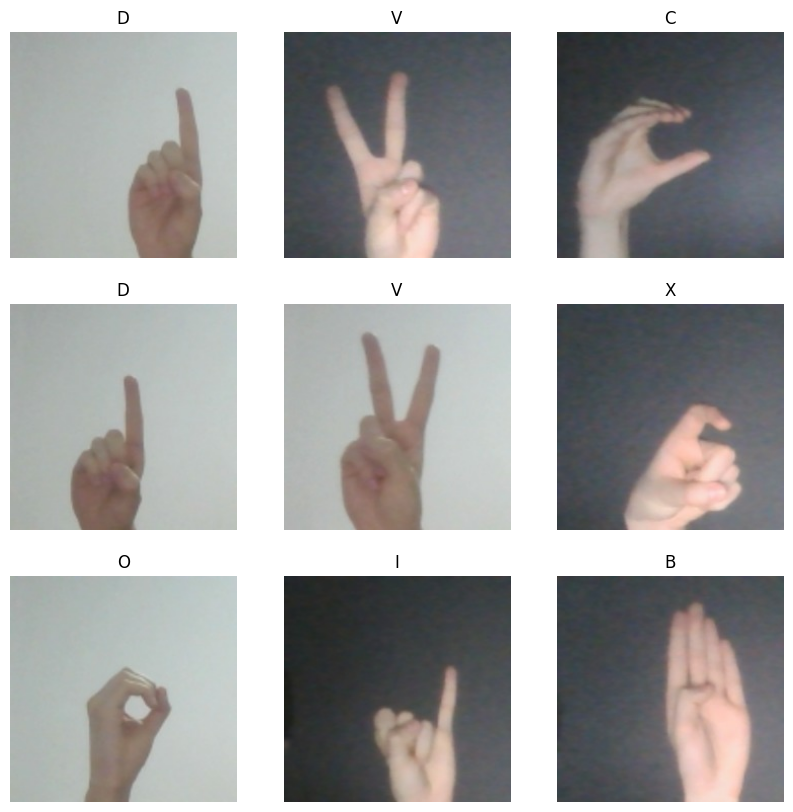

In [4]:
plt.figure(figsize=(10,10))
class_names = train_ds.class_names
for images, labels in train_ds.take(1):  # take first batch
    for i in range(9):  # show 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().argmax()])
        plt.axis("off")

plt.show()

# Autotune for Better results

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)

# Data Augmentation

In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Load pre-trained Model

In [7]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

# Add custom ASL layers

In [8]:
from tensorflow.keras import layers, models

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(24, activation='softmax')
])

# Get model summary

In [9]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 24)                  │           3,096 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,425,048 (9.25 MB)

 Trainable params: 167,064 (652.59 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Compile the Model

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the Model

In [11]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.1731 - loss: 2.8920 - val_accuracy: 0.3458 - val_loss: 2.4064
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.4462 - loss: 2.0696 - val_accuracy: 0.4646 - val_loss: 1.8532
Epoch 3/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.5945 - loss: 1.5646 - val_accuracy: 0.6896 - val_loss: 1.4030
Epoch 4/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.7372 - loss: 1.1976 - val_accuracy: 0.6708 - val_loss: 1.2127
Epoch 5/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 46s 1000ms/step - accuracy: 0.7841 - loss: 0.9648 - val_accuracy: 0.6958 - val_loss: 1.0407
Epoch 6/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.8290 - loss: 0.7961 - val_accuracy: 0.7917 - val_loss: 0.8465
Epoch 7/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.8566 - loss: 0.6623 - val_accuracy: 0.8000 - val_loss: 0.7958
Epoch 8/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.8841 - loss: 0.5702 - val_accuracy: 0.8188 - val_l

In [12]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 776ms/step - accuracy: 0.9074 - loss: 0.3956
Test Accuracy: 0.9074446558952332


# Plot Model Accuracy

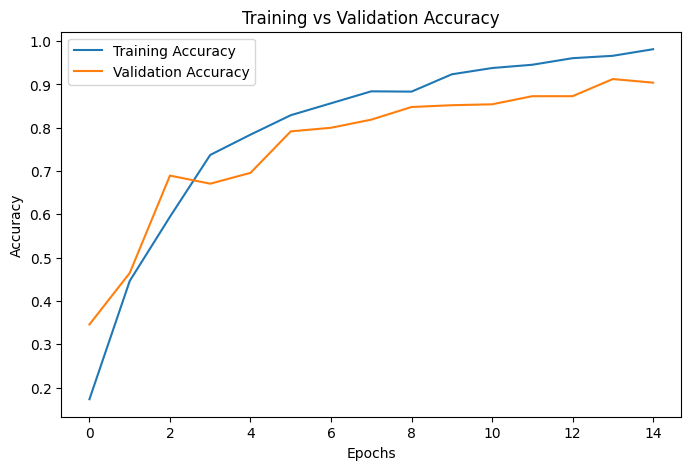

In [13]:
import matplotlib.pyplot as plt

# Extract values
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))


# -------- Accuracy Plot --------
plt.figure(figsize=(8,5))
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')

plt.show()

# Plot Model Loss

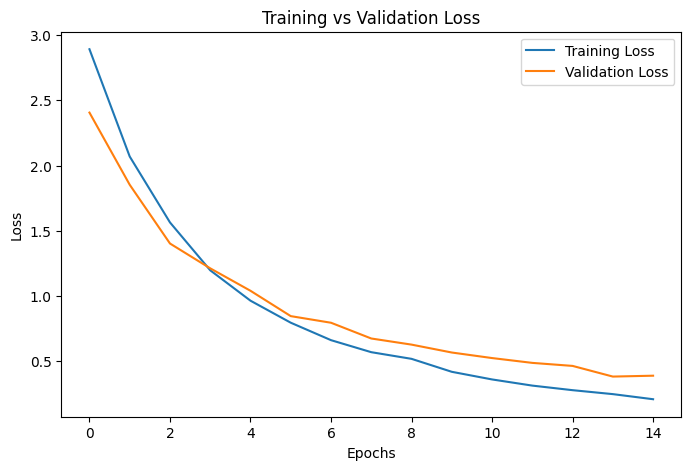

In [14]:
# -------- Loss Plot --------

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(loss))

plt.figure(figsize=(8,5))
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')

plt.show()


# Save the Model

In [15]:
model.save('asl_sign_model.keras')
print("Model Saved Successfully ✅")

Model Saved Successfully ✅
